[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tviskaron/SB-RL-2026/blob/main/seminars/01-crossentropy.ipynb)

# Crossentropy method

This notebook will teach you to solve reinforcement learning problems with crossentropy method. We'll follow-up by scaling everything up and using neural network policy.

**Кросс-энтропийный метод (CEM), табличная версия**

1. Играем `n_sessions` эпизодов текущей стратегией $\pi$
2. Берём топ-(100−percentile)% эпизодов по суммарной награде - "элита"
3. Переобучаем $\pi$ так, чтобы она воспроизводила действия из элитных эпизодов
4. Повторяем

Дальше мы просто реализуем шаги 1–3 по отдельности: `generate_session`, `select_elites`, `get_new_policy`.

In [1]:
try:
    import gymnasium
except ImportError:
    %pip install -q "gymnasium[toy_text]>=1.0,<2.0"

python 3.9.23 | gymnasium 1.1.1 | numpy 2.0.2
start state: 252 | info: {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)}


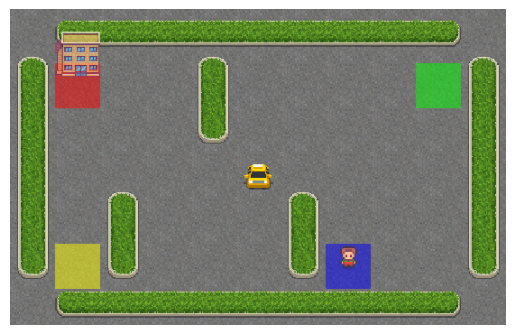

In [24]:
import sys
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print(f"python {sys.version.split()[0]} | gymnasium {gym.__version__} | numpy {np.__version__}")

SEED = 1
np.random.seed(SEED)  # чтобы графики воспроизводились между запусками

env = gym.make("Taxi-v3", render_mode="rgb_array")
obs, info = env.reset(seed=SEED)
print("start state:", obs, "| info:", info)

plt.imshow(env.render())
plt.axis("off");

In [5]:
n_states = env.observation_space.n
n_actions = env.action_space.n

print(f"n_states={n_states}, n_actions={n_actions}")

n_states=500, n_actions=6


# Create stochastic policy

This time our policy should be a probability distribution.

```policy[s,a] = P(take action a | in state s)```

Since we still use integer state and action representations, you can use a 2-dimensional array to represent the policy.

Please initialize the policy __uniformly__, that is, probabililities of all actions should be equal.

In [6]:
def initialize_policy(n_states, n_actions):
    #<YOUR CODE: create an array to store action probabilities>
    policy = np.ones((n_states, n_actions)) / n_actions

    return policy

policy = initialize_policy(n_states, n_actions)

In [7]:
assert type(policy) in (np.ndarray, np.matrix)
assert np.allclose(policy, 1.0 / n_actions)
assert np.allclose(np.sum(policy, axis=1), 1)

# Play the game

Just like before, but we also record all states and actions we took.

In [8]:
def generate_session(env, policy, t_max=10**4):
    """
    Play game until end or for t_max ticks.
    :param policy: an array of shape [n_states,n_actions] with action probabilities
    :returns: list of states, list of actions and sum of rewards
    """
    states, actions = [], []
    total_reward = 0.0

    s, _ = env.reset()

    for t in range(t_max):
        # Hint: you can use np.random.choice for sampling action
        # https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html

        #<YOUR CODE: sample action from policy>
        a = np.random.choice(n_actions, p=policy[s])

        new_s, r, terminated, truncated, _ = env.step(a)

        # Record information we just got from the environment.
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break

    return states, actions, total_reward

In [9]:
s, a, r = generate_session(env, policy)
assert type(s) == type(a) == list
assert len(s) == len(a)
assert type(r) in [float, np.float64]

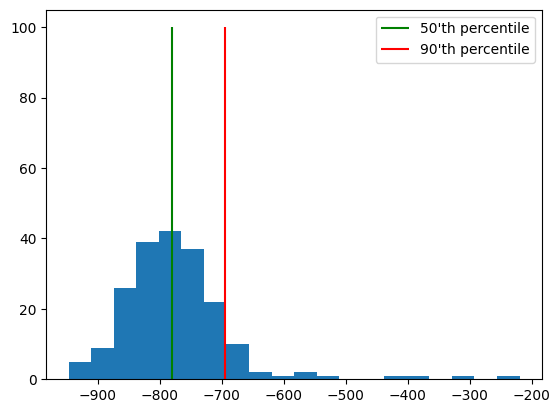

In [11]:
# let's see the initial reward distribution
sample_rewards = [generate_session(env, policy, t_max=1000)[-1] for _ in range(200)]

plt.hist(sample_rewards, bins=20)
plt.vlines([np.percentile(sample_rewards, 50)], [0], [100], label="50'th percentile", color='green')
plt.vlines([np.percentile(sample_rewards, 90)], [0], [100], label="90'th percentile", color='red')
plt.legend()

### Crossentropy method steps

In [12]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)
    (elites, ) = np.where(rewards_batch >= reward_threshold)
    
    elite_states = []
    elite_actions = []
    for i in elites:
        elite_states.extend(states_batch[i])
        elite_actions.extend(actions_batch[i])

    return elite_states, elite_actions

In [13]:
states_batch = [
    [1, 2, 3],     # game1
    [4, 2, 0, 2],  # game2
    [3, 1],        # game3
]

actions_batch = [
    [0, 2, 4],     # game1
    [3, 2, 0, 1],  # game2
    [3, 3],        # game3
]
rewards_batch = [
    3,  # game1
    4,  # game2
    5,  # game3
]

test_result_0 = select_elites(states_batch, actions_batch, rewards_batch, percentile=0)
test_result_30 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=30
)
test_result_90 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=90
)
test_result_100 = select_elites(
    states_batch, actions_batch, rewards_batch, percentile=100
)

assert np.all(test_result_0[0] == [1, 2, 3, 4, 2, 0, 2, 3, 1]) and np.all(
    test_result_0[1] == [0, 2, 4, 3, 2, 0, 1, 3, 3]
), "For percentile 0 you should return all states and actions in chronological order"
assert np.all(test_result_30[0] == [4, 2, 0, 2, 3, 1]) and np.all(
    test_result_30[1] == [3, 2, 0, 1, 3, 3]
), "For percentile 30 you should only select states/actions from two first"
assert np.all(test_result_90[0] == [3, 1]) and np.all(
    test_result_90[1] == [3, 3]
), "For percentile 90 you should only select states/actions from one game"
assert np.all(test_result_100[0] == [3, 1]) and np.all(
    test_result_100[1] == [3, 3]
), "Please make sure you use >=, not >. Also double-check how you compute percentile."

print("Ok!")


Ok!


<details><summary>Что будет, если взять percentile = 90? Подумайте, потом раскройте.</summary>

В элиту попадут только эпизоды с самых удачных стартовых расстановок. Про трудные
старты стратегия не узнает ничего и будет их стабильно проваливать — среднее
просядет, хотя медиана вырастет.
</details>

Мы хотим стратегию, которая максимально правдоподобно объясняет элитные траектории:

$$\pi_{new} = \arg\max_{\pi}\ \frac{1}{N_{\text{total}}}\sum_{(s,a)\in\text{elite}} \log \pi(a\mid s) = \arg\min_{\pi}\ H(\hat p_{\text{elite}}, \pi)$$

где $\hat p_{\text{elite}}$ — эмпирическое распределение пар (состояние, действие) в элитных эпизодах, а $H$ — кросс-энтропия. Отсюда и название.

Кросс-энтропия двух распределений:

$$H(p, q) = -\sum_x p(x) \log q(x)$$


Для табличной политики этот argmin решается в явном виде — это и есть частоты, которые мы считаем ниже. В ДЗ формула будет та же, но $\pi$ станет нейросетью, явного решения не будет, и argmin возьмётся градиентным спуском — то есть буквально `nn.CrossEntropyLoss`.

In [15]:
def get_new_policy(elite_states, elite_actions):
    """
    Given a list of elite states/actions from select_elites,
    return a new policy where each action probability is proportional to

        policy[s_i,a_i] ~ #[occurrences of s_i and a_i in elite states/actions]

    Don't forget to normalize the policy to get valid probabilities and handle the 0/0 case.
    For states that you never visited, use a uniform distribution (1/n_actions for all states).

    :param elite_states: 1D list of states from elite sessions
    :param elite_actions: 1D list of actions from elite sessions

    """

    new_policy = np.zeros([n_states, n_actions])

    #<YOUR CODE: set probabilities for actions given elite states & actions>
    # Don't forget to set 1/n_actions for all actions in unvisited states.
    for s, a in zip(elite_states, elite_actions):
        new_policy[s, a] += 1

    new_policy[np.where(new_policy.sum(axis=1) == 0)] = 1
    new_policy = new_policy / new_policy.sum(axis=1, keepdims=True)

    return new_policy

In [16]:
elite_states = [1, 2, 3, 4, 2, 0, 2, 3, 1]
elite_actions = [0, 2, 4, 3, 2, 0, 1, 3, 3]

new_policy = get_new_policy(elite_states, elite_actions)

assert np.isfinite(
    new_policy
).all(), "Your new policy contains NaNs or +-inf. Make sure you don't divide by zero."
assert np.all(
    new_policy >= 0
), "Your new policy can't have negative action probabilities"
assert np.allclose(
    new_policy.sum(axis=-1), 1
), "Your new policy should be a valid probability distribution over actions"

reference_answer = np.array(
    [
        [1.0, 0.0, 0.0, 0.0, 0.0],
        [0.5, 0.0, 0.0, 0.5, 0.0],
        [0.0, 0.33333333, 0.66666667, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.5, 0.5],
    ]
)
assert np.allclose(new_policy[:4, :5], reference_answer)

print("Ok!")

Ok!


# Training loop
Generate sessions, select N best and fit to those.

In [17]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, policy=None, elapsed=None,
                  reward_range=(-990, 10), plot=True):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    solved = np.mean(np.array(rewards_batch) > 0)  # доля эпизодов с положительной наградой

    # энтропия стратегии: показывает, насколько стратегия ещё исследует,
    # а не схлопнулась в детерминизм
    if policy is None:
        entropy = np.nan
    else:
        entropy = -(policy * np.log(policy + 1e-12)).sum(axis=1).mean()

    log.append([mean_reward, threshold, solved, entropy])

    if not plot:
        return

    mean_rewards, thresholds, solved_rates, entropies = (list(x) for x in zip(*log))

    plt.figure(figsize=[13, 4])

    ax = plt.subplot(1, 3, 1)
    ax.plot(mean_rewards, label="Mean rewards")
    ax.plot(thresholds, label="Reward thresholds")
    ax.axhline(7.9, color="green", ls="--", lw=1, label="оптимум (~7.9)")
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.legend()
    ax.grid()

    ax2 = plt.subplot(1, 3, 2)
    ax2.plot(solved_rates, color="tab:orange", label="Доля успешных эпизодов")
    ax2.set_ylim(-0.05, 1.05)
    ax2.legend(loc="upper left")
    ax2.grid()
    ax3 = ax2.twinx()
    ax3.plot(entropies, color="tab:purple", label="Энтропия стратегии")
    ax3.legend(loc="lower right")

    plt.subplot(1, 3, 3)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    clear_output(True)
    tail = f" | {elapsed:.1f} s/iter" if elapsed is not None else ""
    print(
        f"iter {len(log)} | mean = {mean_reward:.1f} | threshold = {threshold:.1f}"
        f" | solved = {solved:.0%}" + tail
    )
    plt.show()


Чтобы понимать масштаб чисел на графиках:

| | средняя награда | доля успешных эпизодов |
|---|---|---|
| случайная стратегия | −769 | 0% |
| оптимальная стратегия | +7.9 (эпизод ~13 шагов) | 100% |

Оптимум посчитан value iteration — алгоритмом, который мы разберём через пару занятий.

<details><summary>Почему мы обновляем стратегию со сглаживанием (learning_rate = 0.5), а не берём new_policy целиком (learning_rate = 1)? Подумайте, потом раскройте.</summary>

При lr = 1 действие, не попавшее в элиту, получает вероятность ровно 0 — и в этом
состоянии больше никогда не будет сэмплировано, вернуться оно не сможет.
Сглаживание сохраняет исследование. Измерено: lr=1.0 даёт −233, lr=0.5 даёт −49,
lr=0.1 не успевает сойтись (−109).
</details>

iter 100 | mean = -1.6 | threshold = 1.0 | solved = 76% | 0.1 s/iter


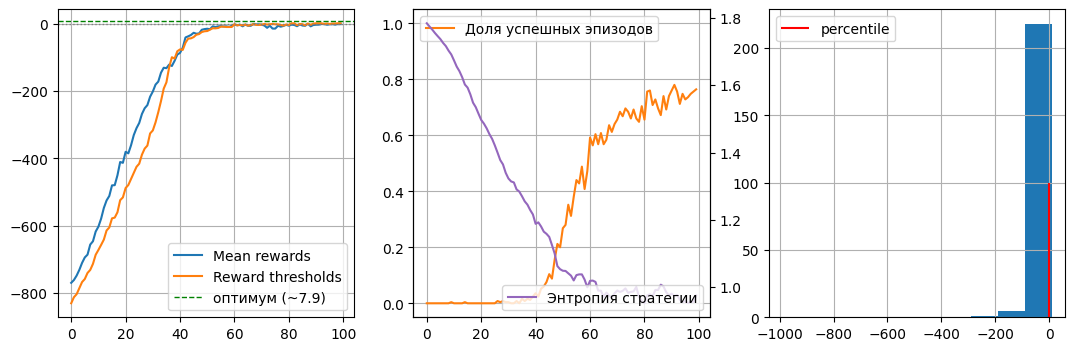

In [ ]:
from time import perf_counter


def train_cem(env, n_sessions=250, percentile=25, learning_rate=0.5,
              n_iterations=100, verbose=True):
    """Обучить табличную стратегию кросс-энтропийным методом.

    Args:
        env: среда gymnasium.
        n_sessions: сколько эпизодов играем на каждой итерации.
        percentile: какой процент худших эпизодов отбрасываем.
        learning_rate: скорость обновления стратегии, от 0 до 1.
        n_iterations: максимальное число итераций.
        verbose: рисовать ли графики прогресса.

    Returns:
        Пара (log, policy): история обучения и итоговая стратегия.
    """
    policy = initialize_policy(n_states, n_actions)
    log = []

    for i in range(n_iterations):
        t0 = perf_counter()

        sessions = [generate_session(env, policy) for _ in range(n_sessions)]
        states_batch, actions_batch, rewards_batch = zip(*sessions)

        elite_states, elite_actions = select_elites(
            states_batch, actions_batch, rewards_batch, percentile
        )
        new_policy = get_new_policy(elite_states, elite_actions)
        policy = learning_rate * new_policy + (1 - learning_rate) * policy

        elapsed = perf_counter() - t0
       
        show_progress(rewards_batch, log, percentile, policy=policy,
                      elapsed=elapsed, plot=verbose)

        if np.mean(rewards_batch) > 0:
            print(f"Решено за {i + 1} итераций!")
            break

    return log, policy


log, policy = train_cem(env)

### Reflecting on results

You may have noticed that the taxi problem quickly converges from less than -1000 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

In case CEM failed to learn how to win from one distinct starting point, it will simply discard it because no sessions from that starting point will make it into the "elites".

To mitigate that problem, you can either reduce the threshold for elite sessions (duct tape way) or change the way you evaluate strategy (theoretically correct way). For each starting state, you can sample an action randomly, and then evaluate this action by running _several_ games starting from it and averaging the total reward. Choosing elite sessions with this kind of sampling (where each session's reward is counted as the average of the rewards of all sessions with the same starting state and action) should improve the performance of your policy.

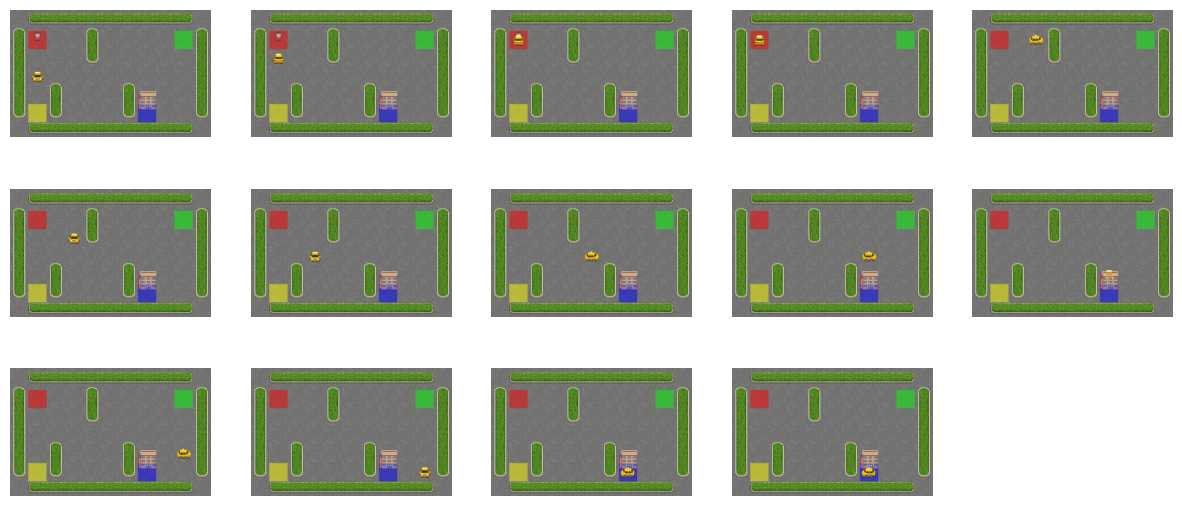

In [21]:
def show_rollout(env, policy, max_steps=20, ncols=5):
    """Прокатить жадную стратегию один эпизод и показать кадры сеткой."""
    frames = []
    s, _ = env.reset()
    frames.append(env.render())
    for _ in range(max_steps):
        s, r, terminated, truncated, _ = env.step(int(np.argmax(policy[s])))
        frames.append(env.render())
        if terminated or truncated:
            break

    nrows = int(np.ceil(len(frames) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 2.2 * nrows))
    for ax, frame in zip(axes.flat, frames):
        ax.imshow(frame)
    for ax in axes.flat:
        ax.axis("off")


show_rollout(env, policy)


### You're not done yet!

Go to [`../homeworks/01-deep-crossentropy.ipynb`](../homeworks/01-deep-crossentropy.ipynb) for a more serious task

In [22]:
env.close()